In [2]:
import pandas as pd
import numpy as np

returns=pd.read_csv(
    "../data/daily_return.csv",
    index_col=0,
    parse_dates=True
)
returns.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005232,-0.012451,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002584,0.004194
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001875
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.010983


In [3]:
expected_daily_return=returns.mean()
expected_daily_return

AAPL     0.001182
AMZN     0.000923
GOOGL    0.001022
MSFT     0.000988
NVDA     0.003050
dtype: float64

In [4]:
annual_return=returns.mean()*252
annual_return

AAPL     0.297892
AMZN     0.232658
GOOGL    0.257607
MSFT     0.248931
NVDA     0.768567
dtype: float64

In [5]:
annual_volatility=returns.std()*np.sqrt(252)
annual_volatility

AAPL     0.316786
AMZN     0.359639
GOOGL    0.324989
MSFT     0.304972
NVDA     0.538788
dtype: float64

In [6]:
cov_matrix=returns.cov()
cov_matrix

,AAPL,AMZN,GOOGL,MSFT,NVDA
AAPL,0.000398,0.000268,0.000265,0.000287,0.000411
AMZN,0.000268,0.000513,0.000300,0.000295,0.000446
GOOGL,0.000265,0.000300,0.000419,0.000293,0.000413
MSFT,0.000287,0.000295,0.000293,0.000369,0.000445
NVDA,0.000411,0.000446,0.000413,0.000445,0.001152


In [7]:
num_assets=len(returns.columns)
weights=np.ones(num_assets)/num_assets
weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [8]:
portfolio_return=np.dot(weights,annual_return)
portfolio_return

np.float64(0.3611310328831976)

In [9]:
portfolio_volatility=np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix*252,weights)
    )
)
portfolio_volatility

np.float64(0.31264741763191733)

In [10]:
risk_free_rate=0.04
sharpe_ratio=(
    portfolio_return-risk_free_rate)/portfolio_volatility

sharpe_ratio

np.float64(1.027134768345562)

In [12]:
portfolio_daily_returns=returns.dot(weights)
cummulative=(1+portfolio_daily_returns).cumprod()
running_max=cummulative.cummax()
drawdown=(cummulative-running_max)/running_max
max_drawdown=drawdown.min()
max_drawdown

np.float64(-0.4182719556590824)

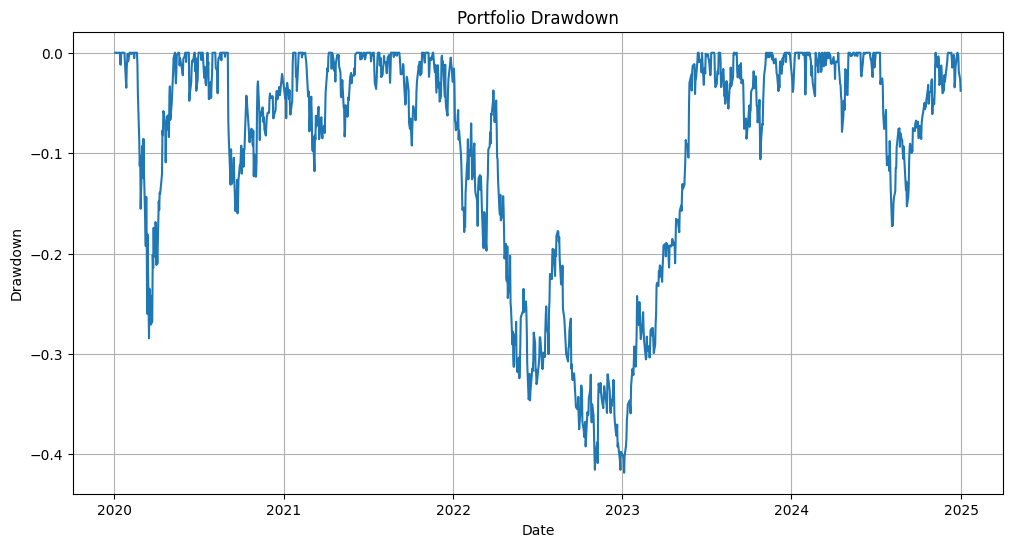

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(drawdown)
plt.title("Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()